<a href="https://colab.research.google.com/github/AaravJain626/ML-DL-using-PyTorch/blob/main/torch_WorkFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.10.0+cpu'

##**1.Data(preparing and loading)**

we will be usig *linear regression formula* to create some known data

the linear regression formula will make a straight line with *known* **parameters**

In [4]:
#Create known parameters 34
weight = 0.7
bias = 0.3

# create
start = 0
end = 1
step = 0.02
X =  torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [5]:
len(X),len(y)

(50, 50)

##Spilitting data into training and test sets(imp)
create training dataset AND test set

In [6]:
# create a train/test split
train_split = int(0.8 * len(X))
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [7]:
#using matplotlib to plot the data for visualization
def plot_prediction(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=None
                    ):
# plots training data,test data and compares predictions

  plt.figure(figsize=(10, 10))
  plt.scatter(train_data, train_labels,c="b",s=4,label="Training Data")

  plt.scatter(test_data,test_labels,c="g",s=10,label="Testing Data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")
    plt.legend(prop={"size":14});


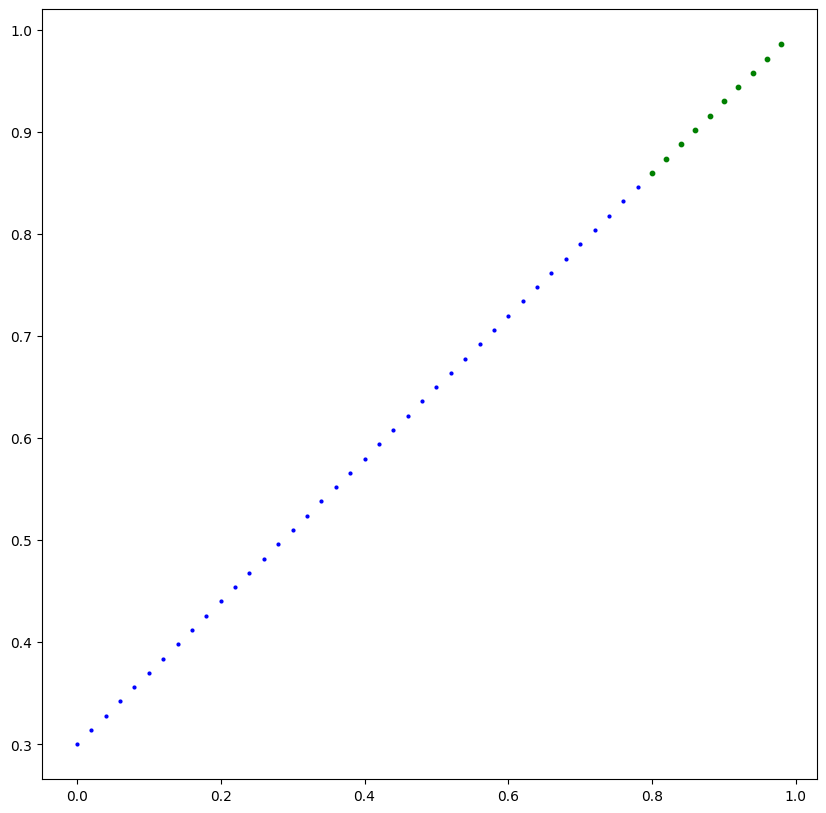

In [8]:
plot_prediction()

##2.Building model
first PyTorch model


In [9]:
from torch import nn
class LinearRegressionModel(nn.Module):#->building brick of PyTorch NNs
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                               requires_grad=True,
                                               dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    # forward method to define the computation in the model
    def forward(self,x: torch.Tensor): #>torch.Tensor
        return self.weights * x + self.bias

###Checking the contents of our PyTorch model
we can check params of our model by using `.parameters().`

In [10]:
#create a random seed
torch.manual_seed(42)

#create and instance of the model(this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

#check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [11]:
# list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

###Making predictions using `torch.inference_mode()`

To check model's predictive power,we will se how well it predicts `y_test` based on `x_test`

In [12]:
# Making predictions with model
with torch.inference_mode():
  y_preds = model_0(X_test)
  print(y_preds)
  # we can also do the same thing with
  # torch.no_grad():


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


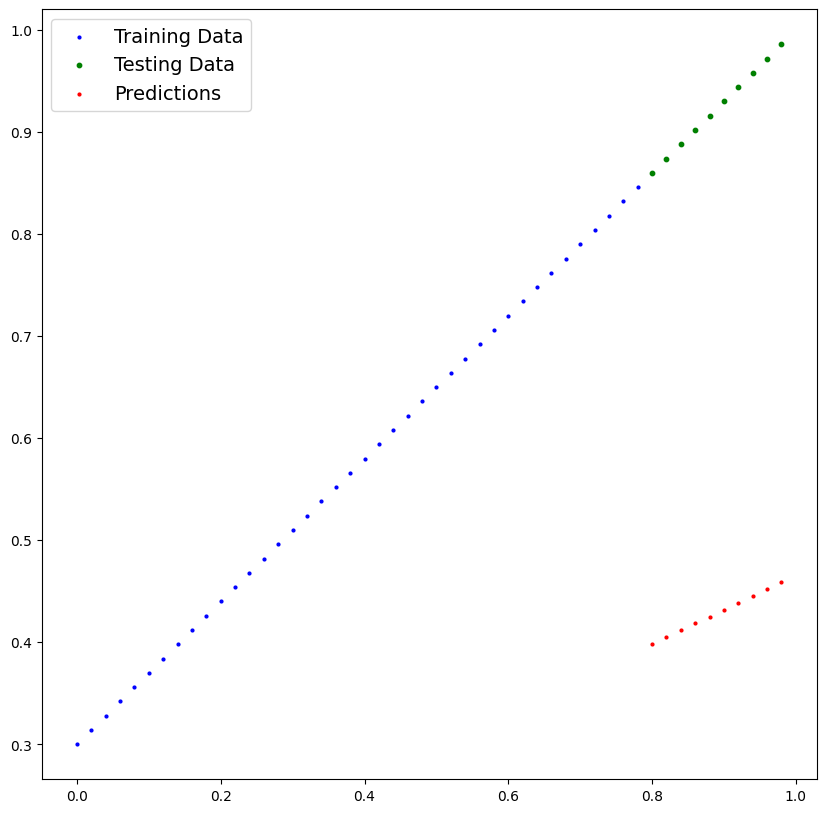

In [13]:
plot_prediction(predictions=y_preds)

In [14]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

###3.Training our model

**giving known parameters**
*A way to measure how wrong the models predictions are is to is use the loss function*

***note:_** Loss function may also be called cost function or criterion in different areas.*

In [15]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [16]:
model_0.state_dict()#check out our model's params(a value that the model  sets itself )

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [25]:
#Setup a loss function
loss_fn = nn.L1Loss()

#Setup an Optimizer(stochastic gradient descent)
optimizer = torch.optim.SGD( params=model_0.parameters(),
                            lr=0.01)#lr = learning rate,Important Hyperparameter



In [26]:
loss_fn

L1Loss()

###buiilding a training loop and testing loop in PyTorch

Things that we need in training loop:

* Loop through the data

* Forward pass:(involves data moving through model's`forward()` functions)-also called forward propagation

* calculate the loss (compare forward pass predictions to ground truth labels)

* Optimizer zero grad
                
* Loss backward - moves backward throgh the network to calculate the gradients of each param of model w.r.t loss(Backpropagation)
                
* Optimizer step: use the optimzer to adjust model's parameters to try and improve the loss(gradient descent)

In [24]:
#epoch is a loop through the data(hyperparameter)
epochs = 1
#Training
#Loop through the data
for epoch in range(epochs):
  #set the model to training mode
  model_0.train() #Train mode sets all parameters that require gradients to require gradient

  #forward pass
  y_pred = model_0(X_train)

  #calculate the loss

  loss = loss_fn(y_pred,y_train)

  #Optimzer zero grad
  optimizer.zero_grad()

  #perform Backpropagation w.r.t to parameters of the model
  loss.backward()

  #step the optimzer
  optimizer.step()

  # model_0.eval() #turns of gradient tracking
